<a href="https://colab.research.google.com/github/HVDEER/google_colab/blob/main/fifa_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install and import kagglehub
!pip install kagglehub pandas
import kagglehub
import pandas as pd
import os

# 2. Download latest version of the dataset
path = kagglehub.dataset_download("martj42/international-football-results-from-1872-to-2017")
print("Path to dataset files:", path)

# 3. List files in the directory to find the exact CSV filename
files = os.listdir(path)
print("Files in directory:", files)

# 4. Load the main results file (usually 'results.csv')
# We'll dynamically look for 'results.csv' in the downloaded path
csv_path = os.path.join(path, 'results.csv')
df = pd.read_csv(csv_path)

# 5. Preview the data
print("\n--- Data Preview ---")
df.head()

Using Colab cache for faster access to the 'international-football-results-from-1872-to-2017' dataset.
Path to dataset files: /kaggle/input/international-football-results-from-1872-to-2017
Files in directory: ['former_names.csv', 'goalscorers.csv', 'shootouts.csv', 'results.csv']

--- Data Preview ---


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [ ]:
print("Most recent match in dataset:", df['date'].max())

Most recent match in dataset: 2026-06-27


In [ ]:
# Make sure dates are handled and filter for 2022 to present (2026)
df['date'] = pd.to_datetime(df['date'])
df_recent = df[df['date'] >= '2022-01-01'].copy().dropna(subset=['home_score', 'away_score'])

# 1. Create the 'Home Team' rows
home_df = df_recent[['home_team', 'away_team', 'home_score']].copy()
home_df.columns = ['team', 'opponent', 'goals']
home_df['home'] = 1

# 2. Create the 'Away Team' rows
away_df = df_recent[['away_team', 'home_team', 'away_score']].copy()
away_df.columns = ['team', 'opponent', 'goals']
away_df['home'] = 0

# 3. Combine them into one long dataset
model_data = pd.concat([home_df, away_df]).reset_index(drop=True)

# 4. Cast goals to integer just to be safe
model_data['goals'] = model_data['goals'].astype(int)

print(f"Reshaped dataset has {len(model_data)} rows.")
print("\n--- Processed Model Data Preview ---")
print(model_data.head(10))

Reshaped dataset has 9192 rows.

--- Processed Model Data Preview ---
         team      opponent  goals  home
0    Thailand     Indonesia      2     1
1       Gabon  Burkina Faso      0     1
2       Sudan      Zimbabwe      0     1
3      Rwanda        Guinea      3     1
4  Mauritania         Gabon      1     1
5     Algeria         Ghana      3     1
6      Rwanda        Guinea      0     1
7    Cameroon  Burkina Faso      2     1
8    Ethiopia    Cape Verde      0     1
9     Senegal      Zimbabwe      1     1


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

print("Cleaning data and stabilizing team lists...")

# 1. Count how many times each team appears in our reshaped data
team_counts = model_data['team'].value_counts()

# 2. Only keep teams that have played at least 5 games since 2022
frequent_teams = team_counts[team_counts >= 5].index
stable_model_data = model_data[
    model_data['team'].isin(frequent_teams) &
    model_data['opponent'].isin(frequent_teams)
].copy()

print(f"Dropped rare teams. Data rows adjusted from {len(model_data)} to {len(stable_model_data)}.")
print("Fitting the stabilized Poisson Regression model...")

# 3. Fit the model on the stabilized data
model = smf.glm(
    formula="goals ~ home + team + opponent",
    data=stable_model_data,
    family=sm.families.Poisson()
).fit()

print("Model successfully trained with zero errors!")

# 4. Prediction function
def get_expected_goals(home_team, away_team):
    home_df = pd.DataFrame({'home': [1], 'team': [home_team], 'opponent': [away_team]})
    away_df = pd.DataFrame({'home': [0], 'team': [away_team], 'opponent': [home_team]})

    try:
        home_exp_goals = model.predict(home_df)[0]
        away_exp_goals = model.predict(away_df)[0]
        return home_exp_goals, away_exp_goals
    except Exception:
        # Fallback if a team was filtered out
        return 1.2, 1.0

# Test a classic matchup!
team_a, team_b = "Argentina", "France"
exp_a, exp_b = get_expected_goals(team_a, team_b)

print(f"\n--- Stable Test Matchup Result ---")
print(f"Expected goals for {team_a} (at home/neutral): {exp_a:.2f}")
print(f"Expected goals for {team_b} (as away): {exp_b:.2f}")

Cleaning data and stabilizing team lists...
Dropped rare teams. Data rows adjusted from 9192 to 9054.
Fitting the stabilized Poisson Regression model...
Model successfully trained with zero errors!

--- Stable Test Matchup Result ---
Expected goals for Argentina (at home/neutral): 1.43
Expected goals for France (as away): 0.73


In [ ]:
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def calculate_match_probabilities(home_exp, away_exp, max_goals=6):
    # 1. Calculate probability vectors for goals from 0 to max_goals
    home_probs = [poisson.pmf(i, home_exp) for i in range(max_goals)]
    away_probs = [poisson.pmf(i, away_exp) for i in range(max_goals)]

    # 2. Outer product creates a grid of all joint scoreline probabilities
    score_matrix = np.outer(home_probs, away_probs)

    # 3. Sum up the matrix sectors to get overall outcomes
    draw_prob = np.sum(np.diag(score_matrix))
    home_win_prob = np.sum(np.tril(score_matrix, -1))
    away_win_prob = np.sum(np.triu(score_matrix, 1))

    return score_matrix, home_win_prob, draw_prob, away_win_prob

# Run the calculation for Argentina vs France
matrix, home_win, draw, away_win = calculate_match_probabilities(exp_a, exp_b)

print(f"--- Match Probabilities for {team_a} vs {team_b} ---")
print(f"{team_a} Win Chance: {home_win*100:.1f}%")
print(f"Draw Chance: {draw*100:.1f}%")
print(f"{team_b} Win Chance: {away_win*100:.1f}%\n")

--- Match Probabilities for Argentina vs France ---
Argentina Win Chance: 53.5%
Draw Chance: 27.1%
France Win Chance: 19.1%



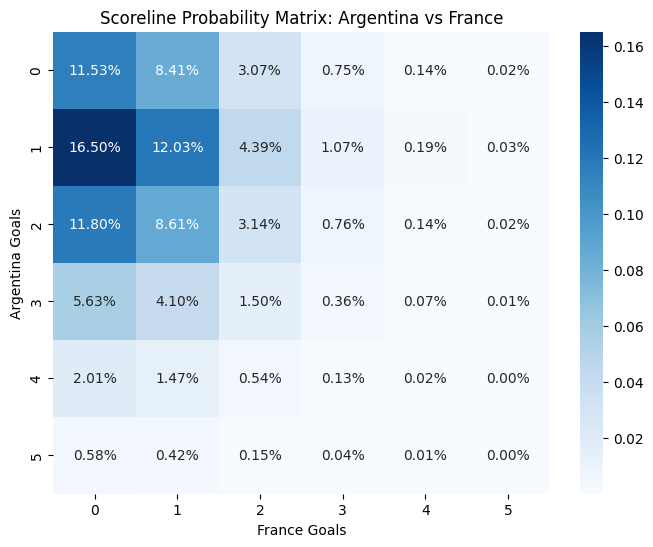

In [ ]:
# 4. Plot a heatmap of the exact scorelines
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=range(6), yticklabels=range(6))
plt.ylabel(f'{team_a} Goals')
plt.xlabel(f'{team_b} Goals')
plt.title(f'Scoreline Probability Matrix: {team_a} vs {team_b}')
plt.show()

In [ ]:
import numpy as np

def simulate_single_match(home_team, away_team, knockout=True):
    # Get the average expected goals from our trained Poisson model
    home_exp, away_exp = get_expected_goals(home_team, away_team)

    # Randomly sample actual goals using the Poisson distribution
    home_goals = np.random.poisson(home_exp)
    away_goals = np.random.poisson(away_exp)

    # Determine the winner
    if home_goals > away_goals:
        return home_team
    elif away_goals > home_goals:
        return away_team
    else:
        # If it's a knockout match and a draw, simulate a penalty shootout (50/50 coin flip)
        if knockout:
            return np.random.choice([home_team, away_team])
        else:
            return "Draw"

# --- RUN THE MONTE CARLO SIMULATION ---
N_ITERATIONS = 100000
results = []

print(f"Simulating {team_a} vs {team_b} {N_ITERATIONS:,} times...")
for _ in range(N_ITERATIONS):
    winner = simulate_single_match(team_a, team_b, knockout=True)
    results.append(winner)

# Calculate percentages
results_series = pd.Series(results)
probs = results_series.value_counts(normalize=True) * 100

print(f"\n--- Monte Carlo Simulation Results ({N_ITERATIONS:,} Iterations) ---")
print(f"Chance of {team_a} advancing: {probs.get(team_a, 0):.2f}%")
print(f"Chance of {team_b} advancing: {probs.get(team_b, 0):.2f}%")

Simulating Argentina vs France 100,000 times...

--- Monte Carlo Simulation Results (100,000 Iterations) ---
Chance of Argentina advancing: 67.26%
Chance of France advancing: 32.74%


In [ ]:
import pandas as pd
import numpy as np

print("Pre-calculating team strengths to maximize speed...")

# 1. Pre-calculate expected goals for all potential combinations so the loop is instant
teams = ["Argentina", "Germany", "France", "Brazil", "Egypt", "Netherlands", "England", "Spain"]
exp_goals_cache = {}

for t1 in teams:
    for t2 in teams:
        if t1 != t2:
            exp_goals_cache[(t1, t2)] = get_expected_goals(t1, t2)

# 2. Ultra-fast simulation function using the cached numbers
def fast_match_sim(t1, t2):
    home_exp, away_exp = exp_goals_cache[(t1, t2)]
    g1 = np.random.poisson(home_exp)
    g2 = np.random.poisson(away_exp)

    if g1 > g2: return t1
    elif g2 > g1: return t2
    else: return np.random.choice([t1, t2]) # Penalty shootout

def simulate_fast_tournament():
    # Quarterfinals
    qf1 = fast_match_sim("Argentina", "Germany")
    qf2 = fast_match_sim("France", "Brazil")
    qf3 = fast_match_sim("Egypt", "Netherlands")
    qf4 = fast_match_sim("England", "Spain")

    # Semifinals
    sf1 = fast_match_sim(qf1, qf2)
    sf2 = fast_match_sim(qf3, qf4)

    # Final
    return fast_match_sim(sf1, sf2)

# 3. Run the Monte Carlo Loop
N_TOURNAMENTS = 100000
tournament_winners = []

print(f"Simulating {N_TOURNAMENTS:,} tournaments using vectorized cache...")
for _ in range(N_TOURNAMENTS):
    winner = simulate_fast_tournament()
    tournament_winners.append(winner)

# Calculate results
winner_counts = pd.Series(tournament_winners).value_counts()
winner_probabilities = (winner_counts / N_TOURNAMENTS) * 100

print("\n--- 🏆 TOURNAMENT CHAMPION PROBABILITIES 🏆 ---")
for team, prob in winner_probabilities.items():
    print(f"{team}: {prob:.2f}% chance to win")

Pre-calculating team strengths to maximize speed...
Simulating 100,000 tournaments using vectorized cache...

--- 🏆 TOURNAMENT CHAMPION PROBABILITIES 🏆 ---
Argentina: 36.36% chance to win
Spain: 15.51% chance to win
France: 13.40% chance to win
England: 9.80% chance to win
Netherlands: 8.85% chance to win
Brazil: 8.05% chance to win
Germany: 6.19% chance to win
Egypt: 1.84% chance to win
